In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.colors import ListedColormap

In [2]:
mutcat_path = "data/mutcat.tsv"
roles_path = "data/generoles.tsv"
twohitfreq_path = "data/pancan_twohitfreq.tsv"
tcgamut_path = "data/tcga_mut_somaticgermline.tsv"
cadd_path = "data/tcga_somgerm_codingnonsyn_newdata_cancergenes_missense_CADD_GRCh37-v1.6.tsv"

In [3]:
mutcat = pd.read_csv(mutcat_path, sep='\t')
roles = pd.read_csv(roles_path, sep = '\t')
twohitfreq = pd.read_csv(twohitfreq_path, sep='\t')
tcgamut = pd.read_csv(tcgamut_path, sep='\t')
cadd = pd.read_csv(cadd_path, sep = '\t',header=1)

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (0,113) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 2C

In [5]:
# preparing dataset

mutcat_roles = pd.merge(mutcat,roles[['Hugo_Symbol','role']],on='Hugo_Symbol',how='left')

df_zygo = mutcat_roles.groupby(['Hugo_Symbol','role','Mutation_Category_genepatient'])['zygosity_genepatient'].value_counts().to_frame().unstack().rename({'zygosity_genepatient':'count'}, axis='columns')
df_zygo.columns = ['_'.join(col).strip() for col in df_zygo.columns.values]
df_zygo = df_zygo.fillna(0).reset_index()
df_zygo['count_total'] = df_zygo['count_2-hit'] + df_zygo['count_1-hit']
df_zygo = df_zygo[df_zygo['count_total']>=5]
df_zygo['2hitfreq'] = df_zygo['count_2-hit']/df_zygo['count_total']

df_zygopivot = df_zygo.pivot(index=['Hugo_Symbol','role'],columns=['Mutation_Category_genepatient'],values='2hitfreq').reset_index()
df_zygopivot = df_zygopivot[['Hugo_Symbol','role','lof','mis','sil']]

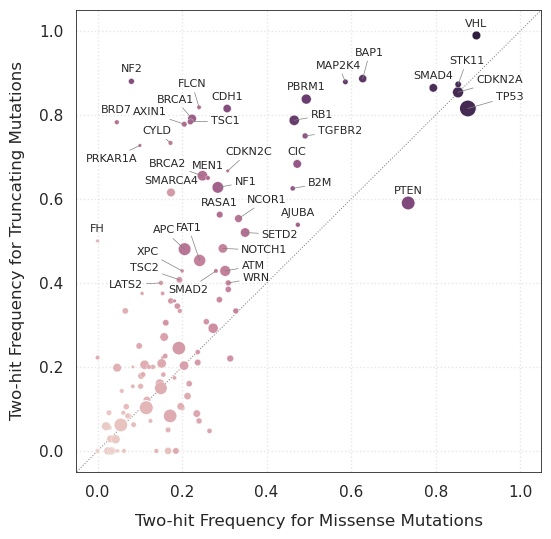

In [6]:
config_rcparams()

sns.set(rc={'figure.figsize':(6,6)})
sns.set_style('white')

genes_to_annotate = {
    "STK11": (6,8),
    "CDKN2A": (30,0),
    "TP53": (30,0),
    "BAP1":(5,10),
    "MAP2K4":(-5,3),
    "TGFBR2":(25,-5),
    "RB1":(20,-5),
    "B2M":(20,-5),
    "AXIN1":(-25,0),
    "FLCN":(-5,8),
    "TSC1":(25,-8),
    "BRCA1":(-12,5),
    "PRKAR1A":(-20,-18),
    "CYLD":(-10,0),
    "BRCA2":(-25,0),
    "CDKN2C":(15,5),
    "NF1":(20,-5),
    "NCOR1":(20,5),
    "SETD2":(25,-10),
    "LATS2":(-25,-10),
    "TSC2":(-25,0),
    "XPC":(-25,5),
    "WRN":(20,-5),
    "SMAD2":(-20,-22),
    "FAT1":(-8,15),
    "APC":(-15,5),
    "ATM":(20,-5),
    "NOTCH1":(30,-10),
}


data = df_zygopivot[df_zygopivot['role']=='TSG'][['Hugo_Symbol','lof','mis']].dropna()
data = pd.merge(data,twohitfreq[['Hugo_Symbol','tot','2hitfreq']], on='Hugo_Symbol')

size_lower = 15
size_upper = np.percentile(data['tot'], 95)

hue_lower = 0.0
hue_upper = data['2hitfreq'].max()

data1 = data[data.tot<=size_upper]
data2 = data[data.tot>size_upper]
ax = sns.scatterplot(data=data1,y='lof',x='mis', hue='2hitfreq', hue_norm=(hue_lower, hue_upper),
                     size='tot',sizes=(5, 80),size_norm=(size_lower, size_upper),legend=False, zorder=1)
ax = sns.scatterplot(data=data2,y='lof',x='mis', hue='2hitfreq', hue_norm=(hue_lower, hue_upper),
                     size='tot',sizes=(100, 150),size_norm=(size_upper, 2867),legend=False, zorder=1)

labelled = data[(data['lof']>=0.4)|(data['mis']>=0.4)]


for _, row in labelled.iterrows():
    x, y = row['mis'], row['lof']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )

        
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)

plt.ylabel('Two-hit Frequency for Truncating Mutations', fontsize=12,labelpad=10)
plt.xlabel('Two-hit Frequency for Missense Mutations', fontsize=12,labelpad=10)
#plt.title('')

ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.spines['right'].set_linewidth(0.6)
ax.spines['top'].set_linewidth(0.6)

cmap_used = ax.collections[0].cmap

plt.show()

----

# Fig 2D

In [7]:
data = df_zygopivot.dropna()

tsglofmis = stats.wilcoxon(data[data.role=='TSG']['lof'].values,data[data.role=='TSG']['mis'].values)
tsgmissil = stats.wilcoxon(data[data.role=='TSG']['mis'].values,data[data.role=='TSG']['sil'].values)
tsglofsil = stats.wilcoxon(data[data.role=='TSG']['lof'].values,data[data.role=='TSG']['sil'].values)

onglofmis = stats.wilcoxon(data[data.role=='ONG']['lof'].values,data[data.role=='ONG']['mis'].values)
ongmissil = stats.wilcoxon(data[data.role=='ONG']['mis'].values,data[data.role=='ONG']['sil'].values)
onglofsil = stats.wilcoxon(data[data.role=='ONG']['lof'].values,data[data.role=='ONG']['sil'].values)

esslofmis = stats.wilcoxon(data[data.role=='essential']['lof'].values,data[data.role=='essential']['mis'].values)
essmissil = stats.wilcoxon(data[data.role=='essential']['mis'].values,data[data.role=='essential']['sil'].values)
esslofsil = stats.wilcoxon(data[data.role=='essential']['lof'].values,data[data.role=='essential']['sil'].values)

neslofmis = stats.wilcoxon(data[data.role=='nonessential']['lof'].values,data[data.role=='nonessential']['mis'].values)
nesmissil = stats.wilcoxon(data[data.role=='nonessential']['mis'].values,data[data.role=='nonessential']['sil'].values)
neslofsil = stats.wilcoxon(data[data.role=='nonessential']['lof'].values,data[data.role=='nonessential']['sil'].values)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ONG_mis vs. ONG_sil: Custom statistical test, P_val:1.213e-01
essential_lof vs. essential_mis: Custom statistical test, P_val:2.074e-25
essential_mis vs. essential_sil: Custom statistical test, P_val:3.357e-01
nonessential_lof vs. nonessential_mis: Custom statistical test, P_val:2.245e-02
nonessential_mis vs. nonessential_sil: Custom statistical test, P_val:1.507e-01
TSG_lof vs. TSG_mis: Custom statistical test, P_val:1.361e-07
TSG_mis vs. TSG_sil: Custom statistical test, P_val:7.892e-04
ONG_lof vs. ONG_mis: Custom statistical test, P_val:7.634e-01
essential_lof vs. essential_sil: Custom statistical test, P_val:3.438e-23
nonessential_lof vs. nonessential_sil: Custom statistical test, P_val:4.388e-01
ONG_lof vs. ONG_sil: Custom statistical test, P_val:3.421e-01
TSG_lof vs. TSG_sil: Custom statisti

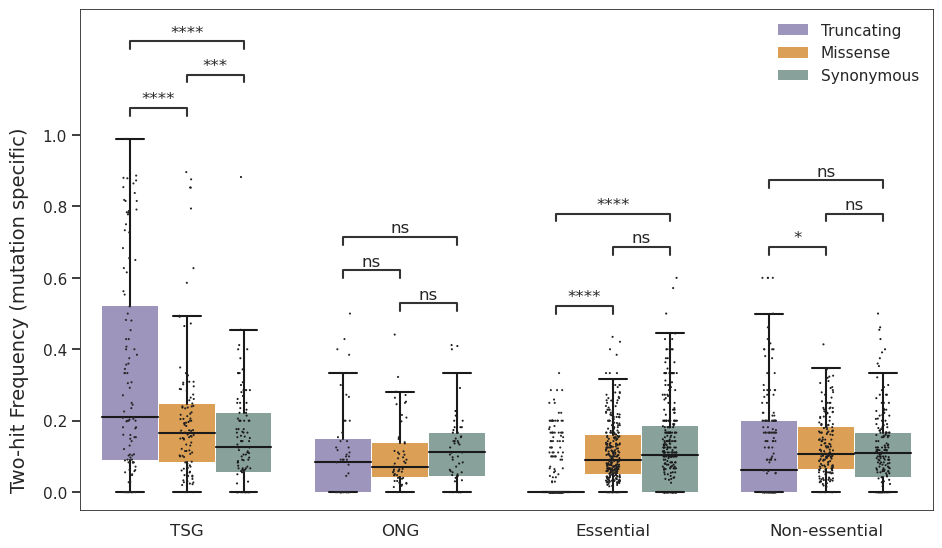

In [8]:
config_rcparams()

sns.set(rc={'figure.figsize':(11,6.5)})
sns.set_style('white')

data = df_zygopivot.dropna()
data = pd.melt(data,id_vars=['Hugo_Symbol','role'],value_vars=['lof','mis','sil'],var_name='mutcat',value_name='2hitfreq')

hue_order = ['lof','mis','sil']
order = ['TSG','ONG','essential','nonessential']
palette = {'lof':'#998ec3','sil':'#84a59d','mis':'#f1a340'}

PROPS = {
    'boxprops':{'edgecolor':'none'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

pairs = [(("TSG", "lof"), ("TSG", "mis")),(("TSG", "mis"), ("TSG", "sil")),(("TSG", "lof"), ("TSG", "sil")),
         (("ONG", "lof"), ("ONG", "mis")),(("ONG", "mis"), ("ONG", "sil")),(("ONG", "lof"), ("ONG", "sil")),
         (("essential", "lof"), ("essential", "mis")),(("essential", "mis"), ("essential", "sil")),(("essential", "lof"), ("essential", "sil")),
         (("nonessential", "lof"), ("nonessential", "mis")),(("nonessential", "mis"), ("nonessential", "sil")),(("nonessential", "lof"), ("nonessential", "sil"))]

pvalues = [tsglofmis.pvalue,tsgmissil.pvalue, tsglofsil.pvalue,
           onglofmis.pvalue,ongmissil.pvalue, onglofsil.pvalue,
           esslofmis.pvalue,essmissil.pvalue, esslofsil.pvalue,
           neslofmis.pvalue,nesmissil.pvalue, neslofsil.pvalue]

with sns.plotting_context('notebook'):
    
    ax=sns.boxplot(data=data,x='role',y='2hitfreq',hue='mutcat',order=order,hue_order=hue_order,showfliers=False,palette=palette,**PROPS)
    ax=sns.stripplot(data=data,x='role',y='2hitfreq',hue='mutcat',order=order,hue_order=hue_order,dodge=True,size=1.5,color='k')#,legend=False)

    annotator = Annotator(ax, pairs, data=data, x='role',y='2hitfreq',hue='mutcat',order=order,hue_order=hue_order)
    annotator.set_pvalues(pvalues)
    annotator.annotate()
    
    plt.ylabel('Two-hit Frequency (mutation specific)', fontsize=14)
    plt.xlabel(None)
    ax.set_xticklabels(['TSG','ONG','Essential','Non-essential'], fontsize=12)
    handles, previous_labels = ax.get_legend_handles_labels()
    legend = ax.legend(handles=handles,labels=['Truncating','Missense','Synonymous'], frameon=False)
    
    for patch in legend.get_patches():
        patch.set_edgecolor("none")
    
plt.xlim(-0.5,3.5)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.set_label_coords(-0.06, 0.4)
ax.tick_params(left=True)

ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.spines['right'].set_linewidth(0.6)
ax.spines['top'].set_linewidth(0.6)

plt.show()

# Fig S3G

In [9]:
# preparing dataset

df_zygo = mutcat_roles.groupby(['Hugo_Symbol','role','CODE','Mutation_Category_genepatient'])['zygosity_genepatient'].value_counts().to_frame().unstack().rename({'zygosity_genepatient':'count'}, axis='columns')
df_zygo.columns = ['_'.join(col).strip() for col in df_zygo.columns.values]
df_zygo = df_zygo.fillna(0).reset_index()
df_zygo['count_total'] = df_zygo['count_2-hit'] + df_zygo['count_1-hit']
df_zygo = df_zygo[df_zygo['count_total']>=5]
df_zygo['2hitfreq'] = df_zygo['count_2-hit']/df_zygo['count_total']
df_zygopivot = df_zygo.pivot(index=['Hugo_Symbol','role','CODE'],columns=['Mutation_Category_genepatient'],values='2hitfreq').reset_index()
df_zygopivot = df_zygopivot[['Hugo_Symbol','role','CODE','lof','mis','sil']]

In [10]:
data = df_zygopivot

tsglofmis = stats.ranksums(data[data.role=='TSG']['lof'].dropna().values,data[data.role=='TSG']['mis'].dropna().values)
tsgmissil = stats.ranksums(data[data.role=='TSG']['mis'].dropna().values,data[data.role=='TSG']['sil'].dropna().values)
tsglofsil = stats.ranksums(data[data.role=='TSG']['lof'].dropna().values,data[data.role=='TSG']['sil'].dropna().values)

onglofmis = stats.ranksums(data[data.role=='ONG']['lof'].dropna().values,data[data.role=='ONG']['mis'].dropna().values)
ongmissil = stats.ranksums(data[data.role=='ONG']['mis'].dropna().values,data[data.role=='ONG']['sil'].dropna().values)
onglofsil = stats.ranksums(data[data.role=='ONG']['lof'].dropna().values,data[data.role=='ONG']['sil'].dropna().values)

esslofmis = stats.ranksums(data[data.role=='essential']['lof'].dropna().values,data[data.role=='essential']['mis'].dropna().values)
essmissil = stats.ranksums(data[data.role=='essential']['mis'].dropna().values,data[data.role=='essential']['sil'].dropna().values)
esslofsil = stats.ranksums(data[data.role=='essential']['lof'].dropna().values,data[data.role=='essential']['sil'].dropna().values)

neslofmis = stats.ranksums(data[data.role=='nonessential']['lof'].dropna().values,data[data.role=='nonessential']['mis'].dropna().values)
nesmissil = stats.ranksums(data[data.role=='nonessential']['mis'].dropna().values,data[data.role=='nonessential']['sil'].dropna().values)
neslofsil = stats.ranksums(data[data.role=='nonessential']['lof'].dropna().values,data[data.role=='nonessential']['sil'].dropna().values)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ONG_mis vs. ONG_sil: Custom statistical test, P_val:5.600e-01
essential_lof vs. essential_mis: Custom statistical test, P_val:2.671e-05
essential_mis vs. essential_sil: Custom statistical test, P_val:5.777e-01
nonessential_lof vs. nonessential_mis: Custom statistical test, P_val:6.258e-02
nonessential_mis vs. nonessential_sil: Custom statistical test, P_val:2.170e-01
TSG_lof vs. TSG_mis: Custom statistical test, P_val:1.273e-12
TSG_mis vs. TSG_sil: Custom statistical test, P_val:3.404e-03
ONG_lof vs. ONG_mis: Custom statistical test, P_val:4.036e-01
essential_lof vs. essential_sil: Custom statistical test, P_val:1.026e-04
nonessential_lof vs. nonessential_sil: Custom statistical test, P_val:1.915e-01
ONG_lof vs. ONG_sil: Custom statistical test, P_val:3.408e-01
TSG_lof vs. TSG_sil: Custom statisti

(-0.5, 3.5)

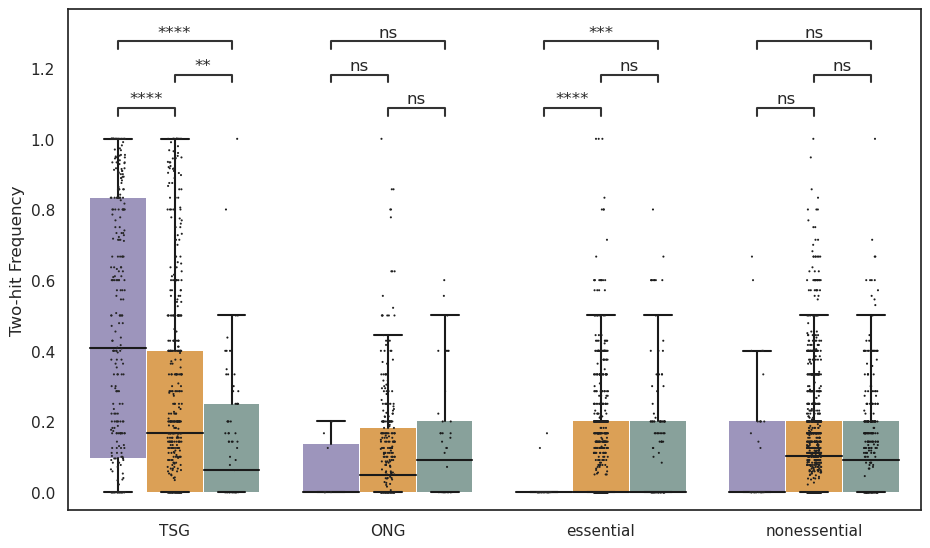

In [11]:
config_rcparams()

sns.set(rc={'figure.figsize':(11,6.5)})
sns.set_style('white')

data = df_zygopivot
data = pd.melt(data,id_vars=['Hugo_Symbol','role'],value_vars=['lof','mis','sil'],var_name='mutcat',value_name='2hitfreq')

hue_order = ['lof','mis','sil']
order = ['TSG','ONG','essential','nonessential']
palette = {'lof':'#998ec3','sil':'#84a59d','mis':'#f1a340'}

PROPS = {
    'boxprops':{'edgecolor':'none'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

pairs = [(("TSG", "lof"), ("TSG", "mis")),(("TSG", "mis"), ("TSG", "sil")),(("TSG", "lof"), ("TSG", "sil")),
         (("ONG", "lof"), ("ONG", "mis")),(("ONG", "mis"), ("ONG", "sil")),(("ONG", "lof"), ("ONG", "sil")),
         (("essential", "lof"), ("essential", "mis")),(("essential", "mis"), ("essential", "sil")),(("essential", "lof"), ("essential", "sil")),
         (("nonessential", "lof"), ("nonessential", "mis")),(("nonessential", "mis"), ("nonessential", "sil")),(("nonessential", "lof"), ("nonessential", "sil"))]

pvalues =  [tsglofmis.pvalue,tsgmissil.pvalue, tsglofsil.pvalue,
           onglofmis.pvalue,ongmissil.pvalue, onglofsil.pvalue,
           esslofmis.pvalue,essmissil.pvalue, esslofsil.pvalue,
           neslofmis.pvalue,nesmissil.pvalue, neslofsil.pvalue]

with sns.plotting_context('notebook'):
    
    ax=sns.boxplot(data=data,x='role',y='2hitfreq',hue='mutcat',order=order,hue_order=hue_order,showfliers=False,palette=palette,**PROPS)
    ax=sns.stripplot(data=data,x='role',y='2hitfreq',hue='mutcat',order=order,hue_order=hue_order,dodge=True,size=1.5,color='k')#,legend=False)

    annotator = Annotator(ax, pairs, data=data, x='role',y='2hitfreq',hue='mutcat',order=order,hue_order=hue_order)
    annotator.set_pvalues(pvalues)
    annotator.annotate()
    
    plt.ylabel('Two-hit Frequency')
    plt.xlabel(None)
    ax.get_legend().remove()
    
plt.xlim(-0.5,3.5)

---

# Fig S3H

In [12]:
# preparing dataset

cadd_mod = cadd[['GeneName','Pos','Ref','Alt','RawScore','PHRED']].drop_duplicates().copy()
cadd_mod.columns=['Hugo_Symbol','Start_Position','Tumor_Seq_Allele1','Tumor_Seq_Allele2','RawScore','PHRED']

tcgamut_cadd = pd.merge(tcgamut[tcgamut['Variant_Type']=='SNP'],cadd_mod,on=['Hugo_Symbol','Start_Position','Tumor_Seq_Allele1','Tumor_Seq_Allele2'])
tcgamut_cadd = pd.merge(tcgamut_cadd,roles[['Hugo_Symbol','role']].rename(columns={'role':'role'}),on='Hugo_Symbol',how='left')
print(len(tcgamut))
print(len(tcgamut[(tcgamut.Variant_Classification=='Missense_Mutation')&(tcgamut.Hugo_Symbol.isin(cadd.GeneName.unique()))]))
print(len(cadd_mod))
print(len(tcgamut_cadd))

1228437
71963
61637
49451


In [13]:
# subsetting those with mis prioritised when >1 mut of diff categories present in same gene patient

print(len(tcgamut_cadd))
mutcat_roles_sub = mutcat_roles[(mutcat_roles['Mutation_Category_genepatient']=='mis')&(mutcat_roles['role'].isin(['TSG','ONG']))]
print(len(mutcat_roles_sub))
tcgamut_cadd_mod = pd.merge(tcgamut_cadd,mutcat_roles_sub[['gene_patient']], on='gene_patient', how='right')
print(len(tcgamut_cadd_mod))

49451
17877
18865


In [14]:
# subsetting those with higher phred value when >1 mis mut present in same gene patient

tcgamut_cadd_mod_nodup = tcgamut_cadd_mod[tcgamut_cadd_mod.duplicated(subset='gene_patient', keep=False)==False]
tcgamut_cadd_mod_dup = tcgamut_cadd_mod[tcgamut_cadd_mod.duplicated(subset='gene_patient', keep=False)==True].sort_values(by='gene_patient')
tcgamut_cadd_mod_dup = tcgamut_cadd_mod_dup.loc[
    tcgamut_cadd_mod_dup.groupby('gene_patient')['PHRED'].idxmax()
].reset_index(drop=True)

tcgamut_cadd_mod = pd.concat([tcgamut_cadd_mod_nodup,tcgamut_cadd_mod_dup])
print(len(tcgamut_cadd_mod)) 

17877


In [15]:
# continued...

tcgamut_cadd['PHRED_category'] = np.nan
tcgamut_cadd['PHRED_category'] = tcgamut_cadd['PHRED_category'].mask(tcgamut_cadd['PHRED']<=23,'low')
tcgamut_cadd['PHRED_category'] = tcgamut_cadd['PHRED_category'].mask(tcgamut_cadd['PHRED']>28,'high')

tcgamut_cadd_mod = tcgamut_cadd[tcgamut_cadd.midan_filter=='keep'].copy()
df_zygo = tcgamut_cadd_mod.groupby(['Hugo_Symbol','role','PHRED_category'])['zygosity'].value_counts().to_frame().unstack().rename({'zygosity':'count'}, axis='columns')
df_zygo.columns = ['_'.join(col).strip() for col in df_zygo.columns.values]
df_zygo = df_zygo.fillna(0).reset_index()
df_zygo['count_total'] = df_zygo['count_2-hit'] + df_zygo['count_1-hit']
print(len(df_zygo))
df_zygo = df_zygo[df_zygo['count_total']>=5]
print(len(df_zygo))
df_zygo['2hitfreq'] = df_zygo['count_2-hit']/df_zygo['count_total']

df_zygopivot = df_zygo.pivot(index=['Hugo_Symbol','role'],columns=['PHRED_category'],values='2hitfreq').reset_index()
print(len(df_zygopivot))
df_zygopivot = df_zygopivot[['Hugo_Symbol','role','high','low']]#.dropna()
print(len(df_zygopivot))

1489
1047
675
675


91 paired TSGs
70 paired ONGs
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ONG_high vs. ONG_low: Custom statistical test, P_val:2.450e-01
TSG_high vs. TSG_low: Custom statistical test, P_val:5.081e-04


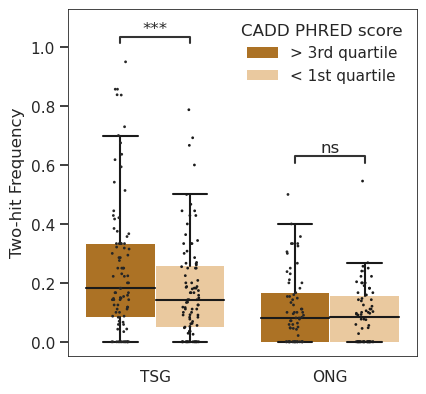

In [16]:
config_rcparams()

sns.set(rc={'figure.figsize':(4.5,4.5)})
sns.set_style('white')

data = df_zygopivot[df_zygopivot.role.isin(['TSG','ONG'])].dropna()
data = pd.melt(data,id_vars=['Hugo_Symbol','role'],value_vars=['high','low'],var_name='PHRED_category',value_name='2hitfreq')

tmp = data[data.role=='TSG'].pivot(index='Hugo_Symbol',columns='PHRED_category',values='2hitfreq').dropna()
print(len(tmp), 'paired TSGs')
p1 = stats.wilcoxon(tmp['high'].values,tmp['low'].values)[1]

tmp = data[data.role=='ONG'].pivot(index='Hugo_Symbol',columns='PHRED_category',values='2hitfreq').dropna()
print(len(tmp), 'paired ONGs')
p2 = stats.wilcoxon(tmp['high'].values,tmp['low'].values)[1]

order=['TSG','ONG']
palette = {'high':'#C2750F','low':'#F7CB92'}

pairs = [(("TSG", "high"), ("TSG", "low")),
         (("ONG", "high"), ("ONG", "low"))]


pvalues =  [p1,p2]

with sns.plotting_context('notebook'):
    
    ax=sns.boxplot(data=data,x='role',y='2hitfreq',hue='PHRED_category',order=order, showfliers=False, palette=palette, **PROPS)#,hue_order=hue_order,,)
    ax=sns.stripplot(data=data,x='role',y='2hitfreq',hue='PHRED_category',color='k',s=2,dodge=True, order=order)#,,hue_order=hue_order,dodge=True,size=1.5,color='k',legend=False)

    annotator = Annotator(data=data,x='role',y='2hitfreq',hue='PHRED_category',order=order, ax=ax, pairs=pairs)
    annotator.set_pvalues(pvalues)
    annotator.annotate()
    
    plt.ylabel('Two-hit Frequency')
    plt.xlabel(None)
    ax.set_xticklabels(['TSG','ONG'])
    handles, previous_labels = ax.get_legend_handles_labels()
    legend = ax.legend(handles=handles,title = 'CADD PHRED score',labels=['> 3rd quartile','< 1st quartile'], frameon=False)
    for patch in legend.get_patches():
        patch.set_edgecolor("none")
    
plt.xlim(-0.5,1.5)
ax.set_yticks(np.arange(0, 1.1, 0.2))
#ax.yaxis.set_label_coords(-0.16, 0.4)
ax.tick_params(left=True)

ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.spines['right'].set_linewidth(0.6)
ax.spines['top'].set_linewidth(0.6)

---